In [1]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join("../")))

import numpy as np
import matplotlib.pyplot as plt
import ultranest
from ultranest.plot import cornerplot

In [2]:
from src.parameters import Parameters
from src.acquisition import Acquisition
from src.forward import forward
from src.layers import create_layers, update_from_arrays

r = compute_reflectivity(h,vp,rho,omegas,p,free_surface,zr,zs)

Wrapper for ``compute_reflectivity``.

Parameters
----------
h : input rank-1 array('d') with bounds (nlay)
vp : input rank-1 array('d') with bounds (nlay)
rho : input rank-1 array('d') with bounds (nlay)
omegas : input rank-1 array('G') with bounds (nw)
p : input rank-1 array('d') with bounds (nkq)
free_surface : input int
zr : input float
zs : input float

Returns
-------
r : rank-2 array('G') with bounds (nw,nkq)



In [3]:
vps_ref = np.array([1500., 1900., 2800., 3800., 2300., 5500.])
#mu = np.array([1500., 2500., 3000., 3000., 3500.])
hs_ref = np.array([150.0, 200.0, 250.0, 380.0, 440.0, 500.0])
rhos_ref = np.array([2000.0, 2000.0, 2000.0, 2000.0, 2000.0, 2000.0])
layers_ref = create_layers(hs_ref, vps_ref, rhos_ref)

In [4]:
# configuration
fs = False
total_time = 2.0    # seconds
f0 = 6.0            # Ricker central frequency (Hz)
f_max = 8.0 * f0    # practical Ricker cutoff
# Nyquist frequency for f_max
dt = 1/(2.*f_max)
nfft = 2**int(np.ceil(np.log2(total_time/dt)))
nfft *= 2 # zero-padding to ensure late wrap-around
nt = int(total_time / dt) + 1
param = Parameters(total_time=total_time, nt=nt, f0=f0, nfft=nfft, epsilon=1.0)
# acquisition
sources = [(30., 76.)]
Nr = 12 # 
x_receivers = np.linspace(100.0, 2500.0, Nr)
receivers = [(x, 76.0) for x in x_receivers]
acq = Acquisition(sources, receivers)
nquad = 64 # 512

In [5]:
d_obs = forward(layers_ref, acq, param, nq_prop=nquad, free_surface=fs)

ampli = np.max(np.abs(d_obs))
noise_level = 0.01 #0.001  # 1% noise
std_noise = noise_level * ampli

print('max trace ampli = ', ampli)
d_obs_noise = np.zeros(d_obs.shape)
noise = np.random.normal(
        loc=0.0,
        scale=std_noise,
        size=d_obs.shape
    )
d_obs_noise = d_obs + noise

max trace ampli =  0.1398021052209811


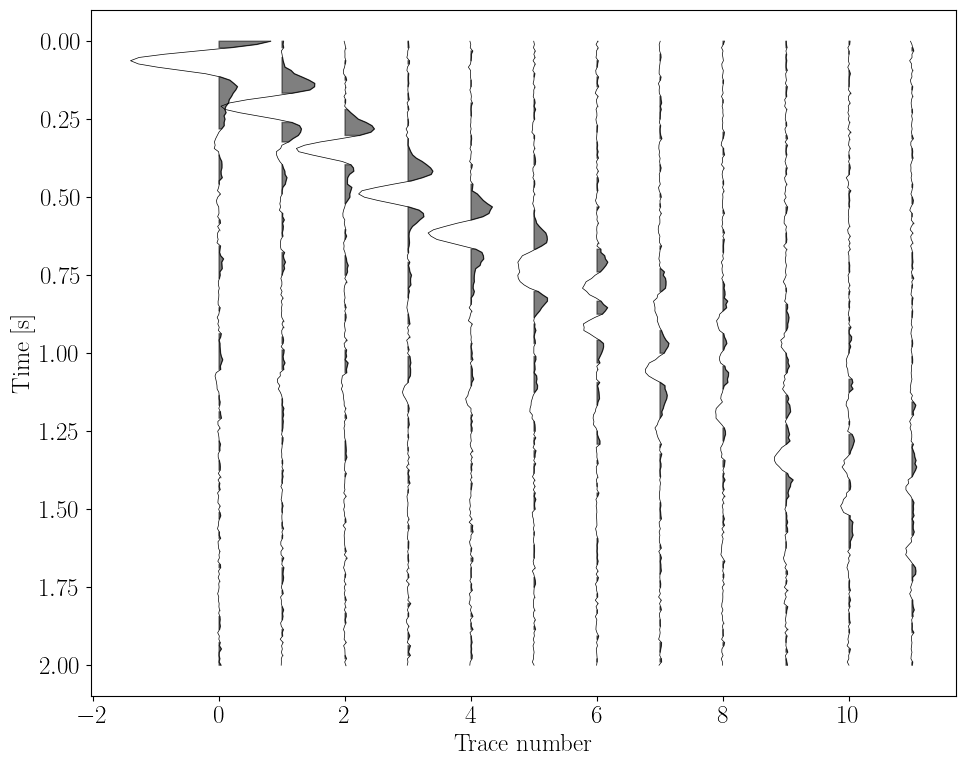

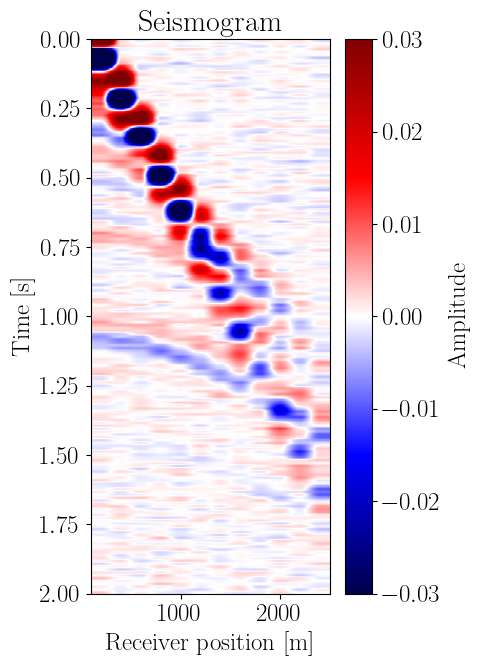

In [6]:
from src.plot.plot_tools import plot_wiggle_traces, plot_seismogram
plot_wiggle_traces(d_obs_noise[0, :, :], xrecvs=x_receivers, time=param.time, trace_step=1, scale=10.)
plot_seismogram(d_obs_noise.T, x_receivers, param.time, vmin=-0.03, vmax=0.03, ncolors=256, figsize=(5,7))

In [7]:
from scipy.linalg import cho_factor, cho_solve

# Number of layers
n_layers = len(vps_ref)

# Prior parameters
sigma = np.array([1000., 1500., 1500., 1500., 1500.])
mu = np.array([2000., 2500., 3000., 3000., 3500.])
cov = np.diag(sigma**2)
chol = cho_factor(cov)

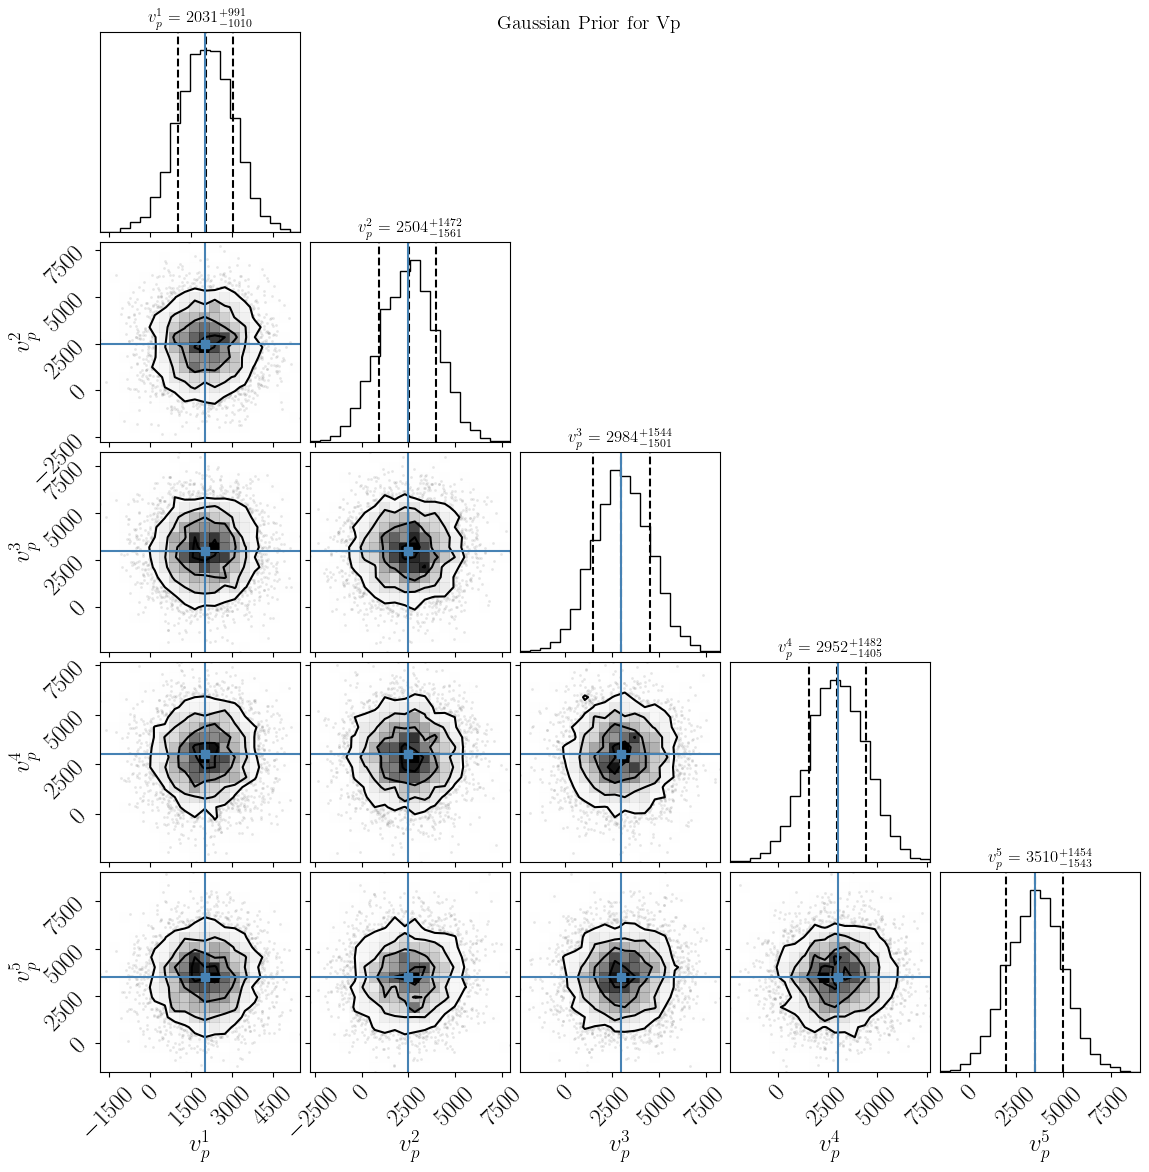

In [8]:
import corner

# Draw 500 samples from the prior
n_samples = 5000
vp_samples = np.random.multivariate_normal(mu, cov, size=n_samples)

# Create corner plot
figure = corner.corner(
    vp_samples,
    labels=[f"$v_p^{i+1}$" for i in range(n_layers)],
    truths=mu,
    show_titles=True,
    title_fmt=".0f",
    quantiles=[0.16, 0.5, 0.84],
    title_kwargs={"fontsize": 12}
)
figure.suptitle("Gaussian Prior for Vp", fontsize=14)
plt.show()

In [9]:
def l2_misfit(dcal, dobs, std_noise):
    nobs = float(dobs.shape[1])
    return 0.5 * param.dt * np.sum((dcal - dobs)**2) / (nobs*std_noise**2) # *(param.dt/nobs)

def log_likelihood(vp):
    vp_new = np.concatenate((vps_ref[0], vp), axis=None)
    layers_new = create_layers(hs=hs_ref, vps=vp_new, rhos=rhos_ref)
    d_cal = forward(layers_new, acq, param, nq_prop=nquad, free_surface=fs)
    log_like = -l2_misfit(d_cal, d_obs_noise, std_noise=std_noise)
    
    return log_like

def log_prior(vp):
    diff = vp - mu
    return -0.5 * diff @ cho_solve(chol, diff)

def log_posterior(vp):
    return log_prior(vp) + log_likelihood(vp)

vp = np.array([1800., 2800., 3800., 2300., 6500.])
print(log_likelihood(vp))
vp = np.array([2000., 3800., 2800., 4300., 5500.])
print(log_likelihood(vp))

-5.830781892411797
-10.237541298376229


In [10]:
'''def function(c0s):
    lay = create_layers(hs=hs_ref, vps=c0s, rhos=rhos_ref)
    d_cal = forward(lay, acq, param, nq_prop=nquad, free_surface=fs)
    err = l2_misfit(d_cal, d_obs, std_noise=0.02)
    return err

def gradient_fd_central(v, eps=1.):
    grad = np.zeros_like(v)
    for i in range(len(v)):
        vp = v.copy()
        vm = v.copy()
        vp[i] += eps
        vm[i] -= eps
        v_p = function(vp)
        v_m = function(vm) 
        print('\n')
        grad[i] = (v_p - v_m) / (2 * eps)
    return grad

v = np.array([1500., 2800., 4800., 2300., 2500.])
grad_fd = gradient_fd_central(v)
print(grad_fd)'''

"def function(c0s):\n    lay = create_layers(hs=hs_ref, vps=c0s, rhos=rhos_ref)\n    d_cal = forward(lay, acq, param, nq_prop=nquad, free_surface=fs)\n    err = l2_misfit(d_cal, d_obs, std_noise=0.02)\n    return err\n\ndef gradient_fd_central(v, eps=1.):\n    grad = np.zeros_like(v)\n    for i in range(len(v)):\n        vp = v.copy()\n        vm = v.copy()\n        vp[i] += eps\n        vm[i] -= eps\n        v_p = function(vp)\n        v_m = function(vm) \n        print('\n')\n        grad[i] = (v_p - v_m) / (2 * eps)\n    return grad\n\nv = np.array([1500., 2800., 4800., 2300., 2500.])\ngrad_fd = gradient_fd_central(v)\nprint(grad_fd)"

In [11]:
vp0 = mu.copy()
print(vp0)
print("log_prior(mu):", log_prior(vp0))
print("log_likelihood(mu):", log_likelihood(vp0))

vp_test = mu + sigma   # one standard deviation perturbation
print("log_prior(vp_test):", log_prior(vp_test))
print("log_likelihood(vp_test):", log_likelihood(vp_test))

[2000. 2500. 3000. 3000. 3500.]
log_prior(mu): 0.0
log_likelihood(mu): -5.424354474704575
log_prior(vp_test): -2.5
log_likelihood(vp_test): -15.204606079185302


In [12]:
def my_prior_transform(cube):
    params = cube.copy()
    # transform location parameter: uniform prior
    lo = 1000
    hi = 7000
    for i in range(len(mu)):
        params[i] = cube[i] * (hi - lo) + lo
    return params
    
def my_likelihood(params):
    c1, c2, c3, c4, c5 = params
    c = np.array([c1, c2, c3, c4, c5])
    return log_posterior(c)

In [13]:
param_names = ['$v_p^2$', '$v_p^3$', '$v_p^4$', '$v_p^5$', '$v_p^6$']
sampler = ultranest.ReactiveNestedSampler(param_names, my_likelihood, my_prior_transform)
result = sampler.run(min_ess=500, min_num_live_points=400, dKL=0.1, dlogz=0.1)

[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-1  40 [-2.0663..-2.0663]*| it/evals=5477/39715 eff=13.9311% N=400  
[ultranest] Likelihood function evaluations: 39715
[ultranest]   logZ = -10.95 +- 0.07847
[ultranest] Effective samples strategy satisfied (ESS = 2785.9, need >500)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.08 nat, need <0.10 nat)
[ultranest] Evidency uncertainty strategy wants 767 minimum live points (dlogz from 0.06 to 0.31, need <0.1)
[ultranest]   logZ error budget: single: 0.12 bs:0.08 tail:0.01 total:0.08 required:<0.10
[ultranest] Widening roots to 767 live points (have 400 already) ...
[ultranest] Sampling 367 live points from prior ...
[ultranest] Explored until L=-1  40 [-2.0416..-2.0409]*| it/evals=10575/78515 eff=13.2620% N=767  
[ultranest] Likelihood function evaluations: 78515
[ultranest]   logZ = -11.05 +- 0.06397
[ultranest] Effective samples strategy satisfied (ESS = 5456.9, need >500)
[ultranest] Posterior uncertainty strategy is satisfied (KL:

In [20]:
sampler.print_results()


logZ = -11.083 +- 0.117
  single instance: logZ = -11.083 +- 0.075
  bootstrapped   : logZ = -11.079 +- 0.117
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    $v_p^2$             : 1594  │ ▁▁▇▆▁▁▁▁▁▁▁▁ ▁▁     ▁               ▁ │4589      1900 +- 54
    $v_p^3$             : 1000  │ ▁▁▁▁▁▁▁▁▂▄▇▅▃▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁│7000      3059 +- 575
    $v_p^4$             : 1000  │▁▁▁▁▂▂▂▃▃▄▅▄▆▅▆▆▇▇▇▇▆▅▄▃▃▂▂▂▁▁▁▁▁▁▁▁▁▁▁│7000      3503 +- 968
    $v_p^5$             : 1000  │▂▂▃▃▄▄▅▆▇▇▇▇▇▇▇▇▆▆▅▅▄▄▄▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁│7000      3155 +- 1064
    $v_p^6$             : 1000  │▂▂▃▃▄▄▄▄▅▆▆▆▆▇▇▇▇▇▆▇▆▅▅▅▄▄▄▃▃▂▂▂▂▂▁▁▁▁▁│7000      3542 +- 1230



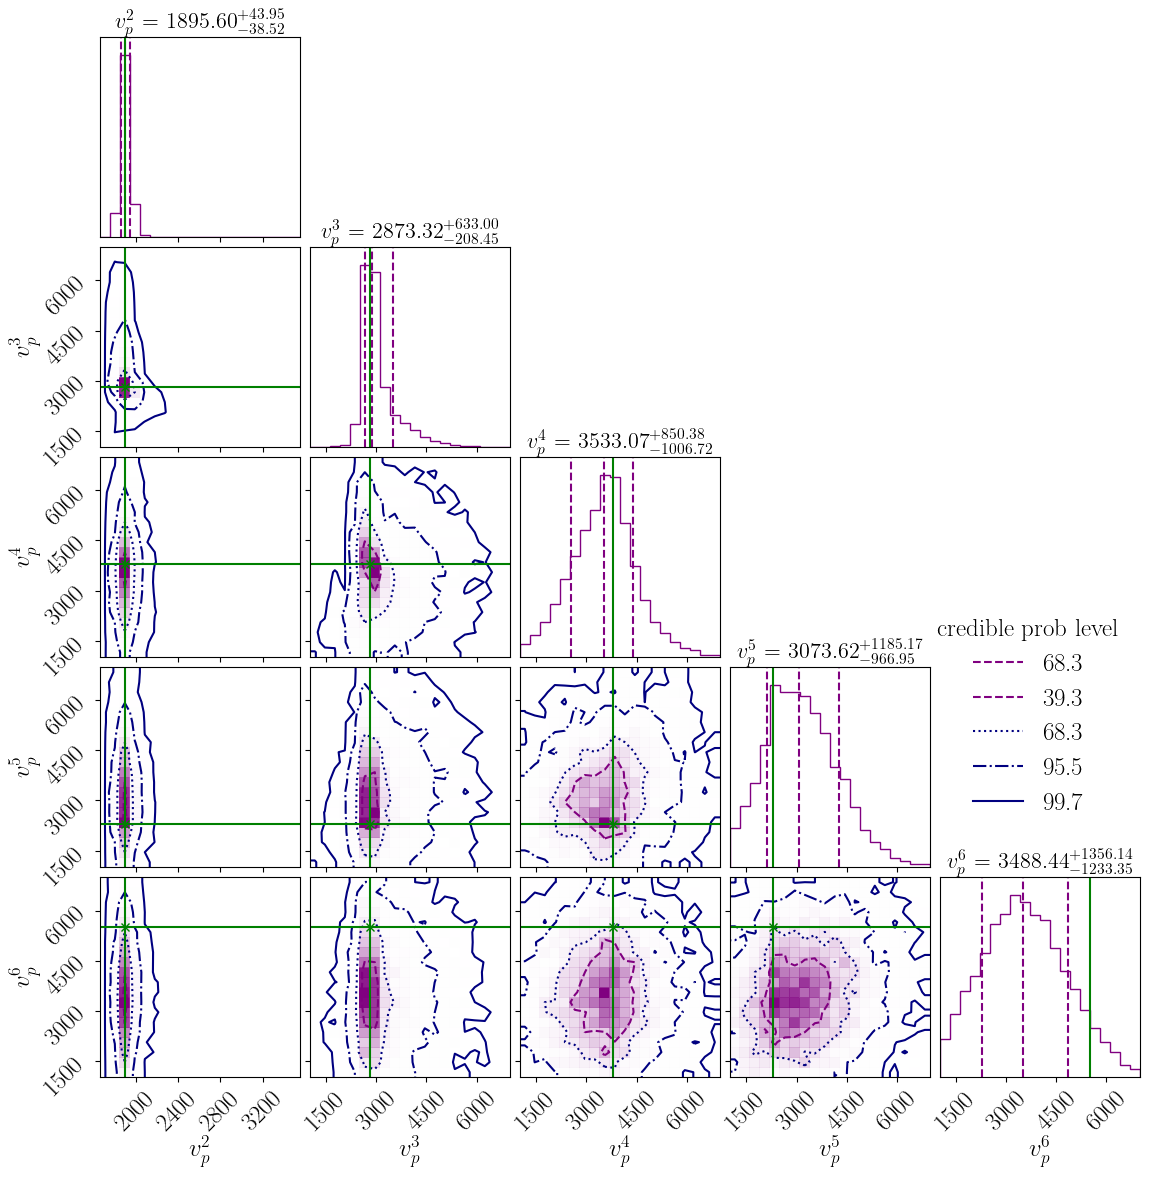

In [19]:
vps_true = np.array([1900., 2800., 3800., 2300., 5500.])

#mu = np.array([1800., 2500., 3000., 3000., 3500.])
#sigma = np.array([500., 800., 1000., 1500., 1500.])
figure = cornerplot(result, plot_density=True, show_titles=True, title_kwargs={"fontsize": 16})
ndim = len(mu)
axes = np.array(figure.axes).reshape((ndim, ndim))
for i in range(ndim):
    ax = axes[i, i]
    #ax.set_xlim(1000., 6000.)
    ax.axvline(vps_true[i], color="g")
# Loop over the histograms
for yi in range(ndim):
    for xi in range(yi):
        ax = axes[yi, xi]
        ax.axvline(vps_true[xi], color="g")
        ax.axhline(vps_true[yi], color="g")
        ax.plot(vps_true[xi], vps_true[yi], "xg")
        #ax.set_xlim(1000., 6000.)
        #ax.set_ylim(1000., 6000.)

plt.show()

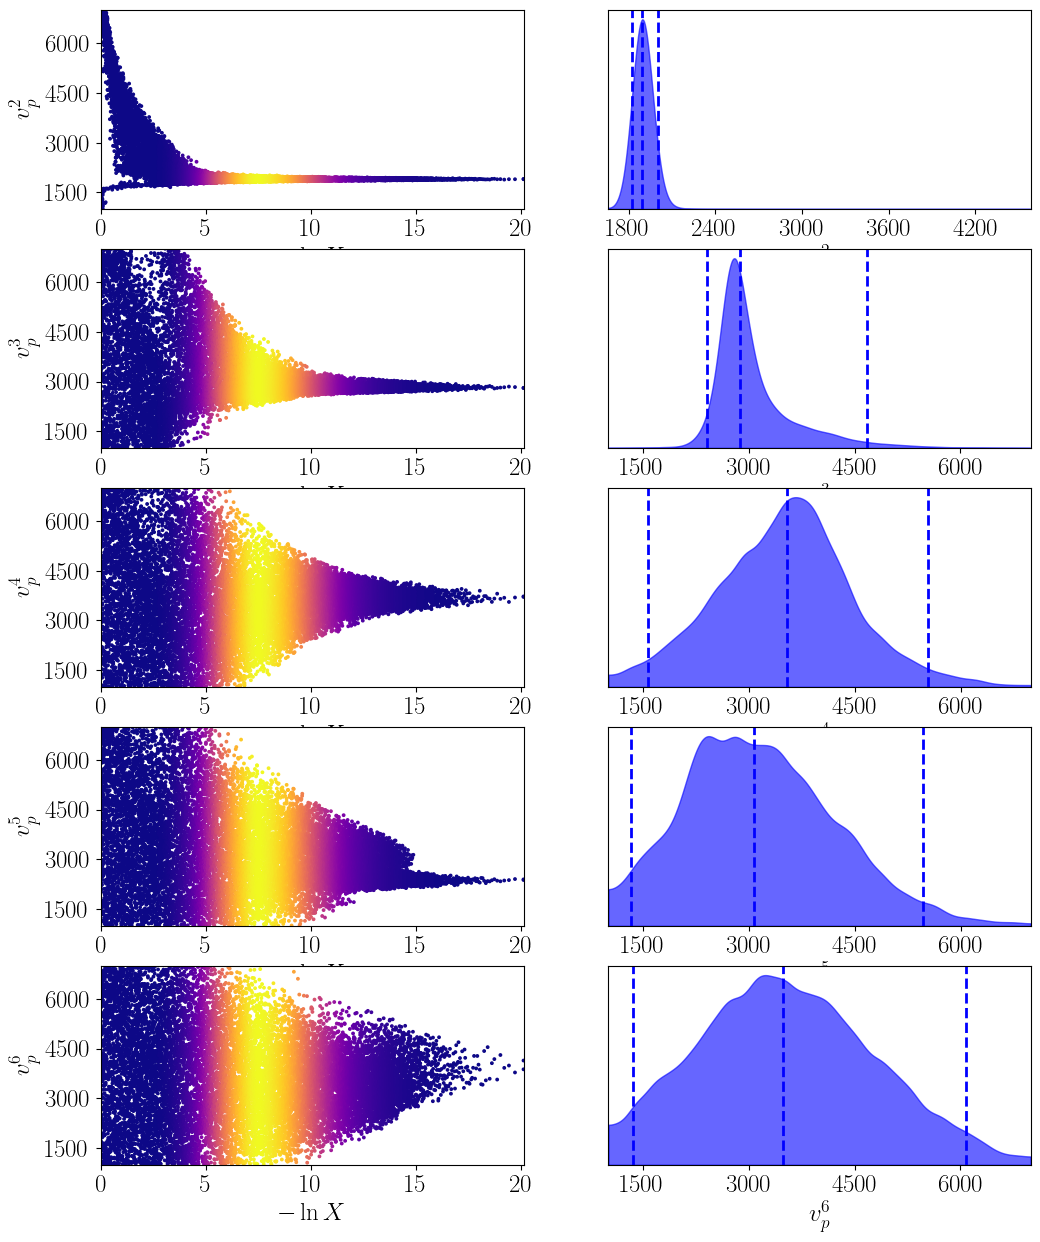

In [16]:
sampler.plot_trace()
plt.show()

In [17]:
print(sampler.results['samples'].shape)
ns = sampler.results['samples'].shape[0]

(15799, 5)


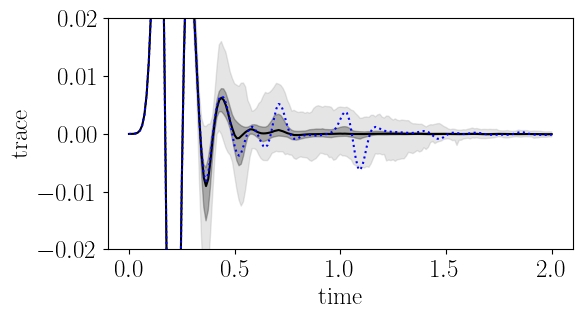

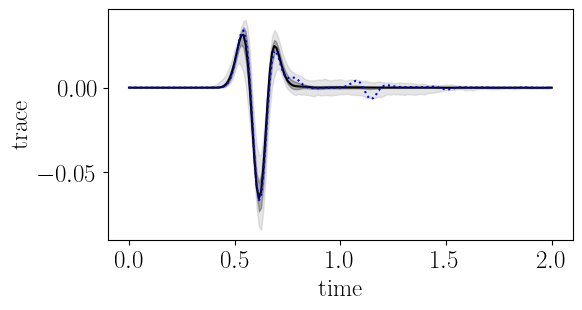

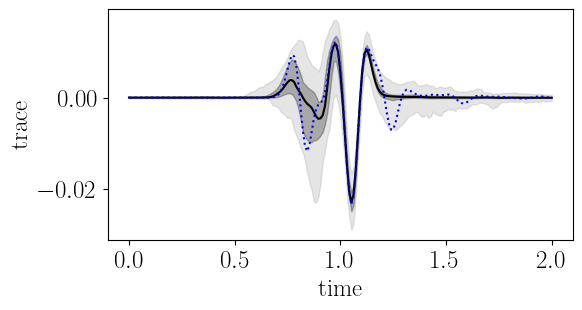

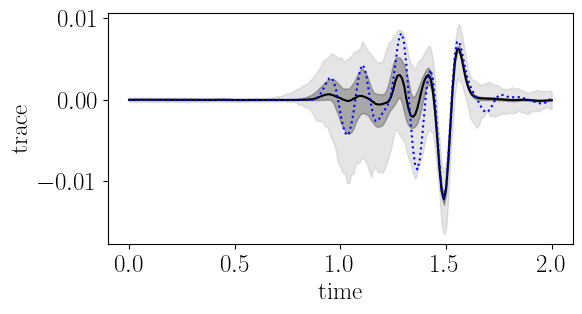

In [18]:
from ultranest.plot import PredictionBand
band1 = PredictionBand(param.time)
band4 = PredictionBand(param.time)
band7 = PredictionBand(param.time)
band10 = PredictionBand(param.time)
# go through the solutions
for vp1, vp2, vp3, vp4, vp5 in sampler.results['samples'][0:ns:10]:
    # compute for each time the y value
    VP = np.array([vps_ref[0], vp1, vp2, vp3, vp4, vp5])
    lays = create_layers(hs=hs_ref, vps=VP, rhos=rhos_ref)
    dcal = forward(lays, acq, param, nq_prop=nquad, free_surface=fs)
    band1.add(dcal[0, 1, :])
    band4.add(dcal[0, 4, :])
    band7.add(dcal[0, 7, :])
    band10.add(dcal[0, 10, :])
    #plt.plot(param.time, dcal[0, 10, :], 'r:')

plt.figure(figsize=(6,3))
plt.xlabel('time')
plt.ylabel('trace')
band1.line(color='k')
band1.shade(color='k', alpha=0.3)
band1.shade(q=0.49, color='gray', alpha=0.2)
plt.plot(param.time, d_obs[0, 1, :], 'b:')
plt.ylim([-0.02,0.02])


plt.figure(figsize=(6,3))
plt.xlabel('time')
plt.ylabel('trace')
band4.line(color='k')
band4.shade(color='k', alpha=0.3)
band4.shade(q=0.49, color='gray', alpha=0.2)
plt.plot(param.time, d_obs[0, 4, :], 'b:')

plt.figure(figsize=(6,3))
plt.xlabel('time')
plt.ylabel('trace')
band7.line(color='k')
band7.shade(color='k', alpha=0.3)
band7.shade(q=0.49, color='gray', alpha=0.2)
plt.plot(param.time, d_obs[0, 7, :], 'b:')

plt.figure(figsize=(6,3))
plt.xlabel('time')
plt.ylabel('trace')
band10.line(color='k')
band10.shade(color='k', alpha=0.3)
band10.shade(q=0.49, color='gray', alpha=0.2)
plt.plot(param.time, d_obs[0, 10, :], 'b:')